Classification of African animals (multi class)- as a beginner

In [24]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import imghdr
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import torchvision.transforms as transforms
import pickle

In [25]:
os.listdir()

['.git',
 '.gitignore',
 'african buffalo.zip',
 'african forest elephants.zip',
 'african lion.zip',
 'african Rhinoceros.zip',
 'african zebra.zip',
 'deployment',
 'image data',
 'main.ipynb',
 'model.pkl']

Inputing images using os

In [26]:
data_dir = "image data"

In [27]:
image_exts = ["jpeg", "jpg", "png", "bmp"]

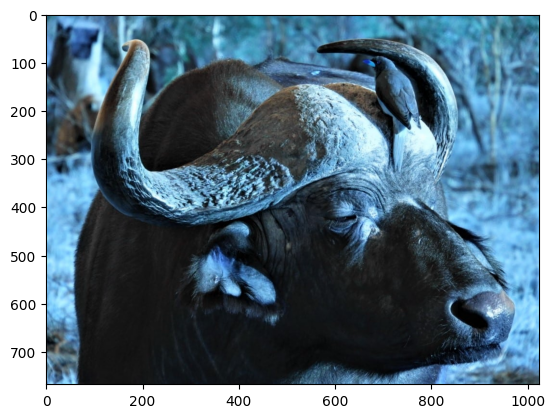

In [28]:
## For learning
image = cv2.imread(r"C:\Users\rahul\OneDrive\Desktop\Rahul\Study\Projects\African animal classifier\image data\african buffalo\4ced6f48.jpg")
image.shape
plt.imshow(image)

In [29]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            image = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print(f"The image {image_path} is not in {image_exts} list")
                os.remove(image_path)
        except Exception as e:
            print(f"Issue with image {image_path}")

In [30]:
from torchvision.datasets import ImageFolder

Labelling the data

In [31]:
dataset = ImageFolder("image data")
print(dataset.imgs[50])
print(dataset.targets[50])
print(dataset.classes)

('image data\\african Rhinoceros\\_WW1195854.jpg', 0)
0
['african Rhinoceros', 'african buffalo', 'african forest elephants', 'african lion', 'african zebra']


ImageFolder handles image loading and labelling
Transform
Test train split

In [ ]:
# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- Stratified split using sklearn ---
from sklearn.model_selection import train_test_split
from torchvision.datasets import ImageFolder

# Load dataset without transform to get targets
full_dataset = ImageFolder("image data")
targets = full_dataset.targets

# Get indices for stratified split
train_indices, test_indices = train_test_split(
    list(range(len(targets))),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

from torch.utils.data import Subset

# Create train and test datasets with correct transforms
train_dataset = Subset(ImageFolder("image data", transform=train_transform), train_indices)
test_dataset = Subset(ImageFolder("image data", transform=test_transform), test_indices)

Creating Dataloaders for the datasets

In [33]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

CNN model

In [34]:
class CNNModel(torch.nn.Module):
    def __init__(self, input_chanels):
        super(CNNModel, self).__init__()
        self.features = torch.nn.Sequential(
            torch.nn.Conv2d(input_chanels, 32, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm2d(32),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),

            torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm2d(64),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 56 * 56, 128),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.5),

            torch.nn.Linear(128, 64),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.5),

            torch.nn.Linear(64, 5)

        )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Hyperparameters 

In [35]:
learning_rate = 1e-5
num_epochs = 25

Instanciation of Model

In [36]:
model = CNNModel(input_chanels=3)
criterion = torch.nn.CrossEntropyLoss() # For multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

To GPU

In [37]:
train_mode = True  # set to False if you want to skip training and just load model

# pick device once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# move model & loss function once
model = CNNModel(input_chanels=3).to(device)
criterion = torch.nn.CrossEntropyLoss().to(device)

# optimizer stays the same (it tracks parameters, not device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# filename for saving/loading model
model_path = "deployment/animal_classifier.pth"

Using device: cuda


Training loop

In [38]:
if train_mode:
    print("Training model...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    # save model after training
    torch.save(model.state_dict(), model_path)
    print(f"✅ Model saved to {model_path}")

else:
    print("Loading pre-trained model...")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"✅ Model loaded from {model_path}")


with open("model.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)

Training model...
Epoch [1/25], Loss: 1.4724
Epoch [2/25], Loss: 1.2779
Epoch [3/25], Loss: 1.1800
Epoch [4/25], Loss: 1.1121
Epoch [5/25], Loss: 1.0750
Epoch [6/25], Loss: 1.0105
Epoch [7/25], Loss: 0.9897
Epoch [8/25], Loss: 0.9458
Epoch [9/25], Loss: 0.9187
Epoch [10/25], Loss: 0.8518
Epoch [11/25], Loss: 0.8398
Epoch [12/25], Loss: 0.8124
Epoch [13/25], Loss: 0.8176
Epoch [14/25], Loss: 0.7863
Epoch [15/25], Loss: 0.7458
Epoch [16/25], Loss: 0.6948
Epoch [17/25], Loss: 0.7010
Epoch [18/25], Loss: 0.6730
Epoch [19/25], Loss: 0.6314
Epoch [20/25], Loss: 0.6405
Epoch [21/25], Loss: 0.6096
Epoch [22/25], Loss: 0.5660
Epoch [23/25], Loss: 0.5751
Epoch [24/25], Loss: 0.5493
Epoch [25/25], Loss: 0.5595
✅ Model saved to deployment/animal_classifier.pth


Model Evaluation

In [39]:
model.eval()

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU(inplace=True)
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=64, out_features=5, bias=True)
  )
)

In [40]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.66%
